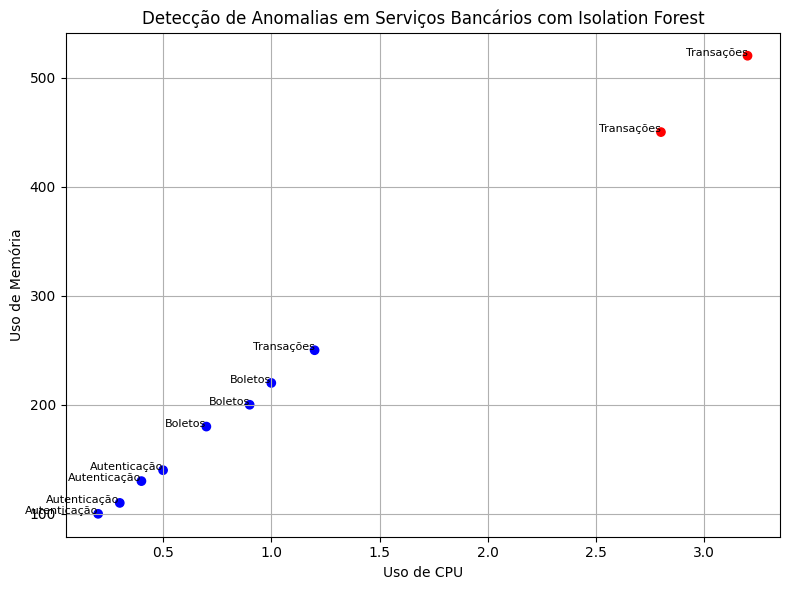

        servico  cpu_usage  memory_usage  anomaly
0  Autenticação        0.3           110        1
1       Boletos        0.7           180        1
2    Transações        1.2           250        1
3  Autenticação        0.4           130        1
4       Boletos        0.9           200        1
5    Transações        2.8           450       -1
6  Autenticação        0.5           140        1
7       Boletos        1.0           220        1
8    Transações        3.2           520       -1
9  Autenticação        0.2           100        1


<Figure size 640x480 with 0 Axes>

In [1]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Simulação de métricas reais de serviços bancários
data = pd.DataFrame({
    'servico': [
        'Autenticação', 'Boletos', 'Transações', 'Autenticação', 'Boletos',
        'Transações', 'Autenticação', 'Boletos', 'Transações', 'Autenticação'
    ],
    'cpu_usage': [0.3, 0.7, 1.2, 0.4, 0.9, 2.8, 0.5, 1.0, 3.2, 0.2],
    'memory_usage': [110, 180, 250, 130, 200, 450, 140, 220, 520, 100]
})

# Normalização das métricas
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['cpu_usage', 'memory_usage']])

# Aplicação do modelo Isolation Forest
model = IsolationForest(contamination=0.2, random_state=42)
data['anomaly'] = model.fit_predict(scaled_data)

# Visualização dos resultados
plt.figure(figsize=(8, 6))
colors = data['anomaly'].map({1: 'blue', -1: 'red'})
plt.scatter(data['cpu_usage'], data['memory_usage'], c=colors)

# Adicionar rótulos dos serviços
for i, row in data.iterrows():
    plt.text(row['cpu_usage'], row['memory_usage'], row['servico'], fontsize=8, ha='right')

plt.xlabel('Uso de CPU')
plt.ylabel('Uso de Memória')
plt.title('Detecção de Anomalias em Serviços Bancários com Isolation Forest')
plt.grid(True)
plt.tight_layout()
plt.show()

# Exibir tabela com resultados
print(data)

plt.savefig("../docs/anomalia-servicos.png")
plt.show()
